# Is the judge (`/sedzia`) a well-behaved comparator?

The scoring model is only reachable through `POST /sedzia`, which takes two 800 bp
sequences and answers *which one is stronger*. Everything we build on top of it --
ranking, hill-climbing, tournament selection -- silently assumes the judge behaves
like a comparison function. This notebook checks that assumption on the 100 natural
promoters in `HackThePromotor/Promotory.csv`.

Three properties, in the order they matter:

| property | question | what breaks if it fails |
|---|---|---|
| **determinism** | same pair, same answer every time? | nothing is reproducible; every measurement needs repeats |
| **symmetry** | does `sedzia(a, b)` agree with `sedzia(b, a)`? | verdicts encode call order, not biology |
| **transitivity** | `a > b` and `b > c` imply `a > c`? | no consistent ranking exists; sorting is meaningless |

Budget note: `/sedzia` allows 600 calls/min and the team has a 20 000/day quota.
The whole notebook costs roughly **790 calls** and runs in about three minutes.

In [20]:
import itertools
import random
import sys
import time
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from threading import Lock

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
sys.path.insert(0, str(ROOT / "src"))

from hack_the_bromoter.api import me, sedzia  # noqa: E402

account = me()
print("team:", account["druzyna"], "| used today:", account["zuzycie_dzis"],
      "/", account["dzienny_limit_druzyny"], "| /sedzia per minute:",
      account["limity_na_minute"]["/sedzia"])

team: druzyna_05 | used today: 3634 / 200000 | /sedzia per minute: 3000


In [21]:
promoters = pd.read_csv(ROOT / "HackThePromotor" / "Promotory.csv", sep=";")
SEQ = dict(zip(promoters["nazwa"], promoters["sekwencja"]))
NAMES = list(SEQ)

print(f"{len(NAMES)} sequences, lengths {set(promoters['dlugosc'])}, "
      f"N bases total {promoters['N'].sum()}")
promoters.head(3)[["nazwa", "gatunek", "dlugosc", "N"]]

100 sequences, lengths {800}, N bases total 0


,nazwa,gatunek,dlugosc,N
0,B10_G000242,B10,800,0
1,F7_G010122,F7,800,0
2,I1237_G008125,I1237,800,0


## The call layer

`/sedzia` is capped at 600 calls per minute, so calls go through a global
token-gap limiter (a shared "next free slot" clock) and a small thread pool.
Every experiment below reports how many calls it spent.

In [ ]:
RATE_PER_MIN = 540          # server allows 600; leave headroom for retries
WORKERS = 6

_gap = 60.0 / RATE_PER_MIN
_lock = Lock()
_next_slot = [0.0]
_calls = Counter()


def judge(a, b, nazwa_a="a", nazwa_b="b"):
    """One rate-limited /sedzia call on two sequence *names* from the CSV."""
    with _lock:
        now = time.monotonic()
        wait = max(0.0, _next_slot[0] - now)
        _next_slot[0] = max(_next_slot[0], now) + _gap
        _calls["total"] += 1
    if wait:
        time.sleep(wait)
    answer = sedzia(SEQ[a], SEQ[b], nazwa_a=nazwa_a, nazwa_b=nazwa_b)
    idx = answer["silniejsza_idx"]
    return {"a": a, "b": b, "idx": idx, "winner": (a, b)[idx],
            "uwaga": answer.get("uwaga", "")}


def judge_many(calls, workers=WORKERS):
    """Run many judge() argument tuples in parallel, results in input order."""
    with ThreadPoolExecutor(workers) as pool:
        return list(pool.map(lambda c: judge(*c), calls))


def spent(label, before):
    print(f"[{label}] {_calls['total'] - before} calls, "
          f"{_calls['total']} so far")


rng = random.Random(0)

## 1. Determinism

40 random pairs, each asked **5 times**, with all 200 calls shuffled so the repeats
of one pair are scattered across the run rather than sent back to back.

Caveat worth stating up front: this test cannot separate *a deterministic model*
from *a server-side cache of the answer*. Either way the practical consequence is
the same -- one call per pair is enough -- but it means a re-run tomorrow, after a
cache expiry or a model reload, is not guaranteed to reproduce these verdicts.

In [4]:
REPEATS = 5
det_pairs = [tuple(rng.sample(NAMES, 2)) for _ in range(40)]

before = _calls["total"]
work = [pair for pair in det_pairs for _ in range(REPEATS)]
rng.shuffle(work)
det_results = judge_many(work)
spent("determinism", before)

by_pair = defaultdict(list)
for r in det_results:
    by_pair[(r["a"], r["b"])].append(r["idx"])

unstable = {pair: v for pair, v in by_pair.items() if len(set(v)) > 1}
DETERMINISTIC = not unstable

print(f"\n{len(by_pair)} pairs x {REPEATS} repeats = {len(det_results)} calls")
print(f"pairs that changed their mind: {len(unstable)}")
for pair, verdicts in list(unstable.items())[:5]:
    print("  ", pair, verdicts)
print("\nverdict:", "DETERMINISTIC" if DETERMINISTIC else "NOT deterministic")

[determinism] 200 calls, 200 so far

40 pairs x 5 repeats = 200 calls
pairs that changed their mind: 0

verdict: DETERMINISTIC


In [5]:
# How often does the judge warn that an input barely looks like a promoter?
warnings = Counter(r["uwaga"].split(":")[0] or "(none)" for r in det_results)
for text, n in warnings.most_common():
    print(f"{n:5d}  {text}")

  105  (none)
   95  slabo przypomina promotor


## 2. Symmetry

A comparator must not care which slot a sequence is handed to. Two probes:

* **`sedzia(a, a)`** -- the same sequence in both slots. Whatever comes back is the
  judge's tie-break, and it exposes any preference for a slot.
* **`sedzia(a, b)` vs `sedzia(b, a)`** -- 100 random pairs asked in both orders. The
  answers agree only if the *same sequence* wins both times.

A third, cheaper probe: the `nazwa_a` / `nazwa_b` labels are metadata, so changing
them must not change the verdict.

In [6]:
before = _calls["total"]
self_results = judge_many([(n, n) for n in rng.sample(NAMES, 20)])
spent("self-comparison", before)

self_idx = Counter(r["idx"] for r in self_results)
print("\nsedzia(a, a) -> winner index:", dict(self_idx))
print("tie-break slot:", "always A (index 0)" if self_idx[1] == 0
      else "always B (index 1)" if self_idx[0] == 0 else "mixed")

[self-comparison] 20 calls, 220 so far

sedzia(a, a) -> winner index: {0: 20}
tie-break slot: always A (index 0)


In [7]:
before = _calls["total"]
sym_pairs = [tuple(rng.sample(NAMES, 2)) for _ in range(100)]
forward = judge_many(sym_pairs)
reverse = judge_many([(b, a) for a, b in sym_pairs])
spent("symmetry", before)

consistent = [f["winner"] == r["winner"] for f, r in zip(forward, reverse)]
SYMMETRIC_RATE = sum(consistent) / len(consistent)
slot_bias = Counter(r["idx"] for r in forward + reverse)
flip_pattern = Counter((f["idx"], r["idx"])
                       for f, r, ok in zip(forward, reverse, consistent) if not ok)

print(f"\norder-consistent pairs: {sum(consistent)}/{len(consistent)} "
      f"({SYMMETRIC_RATE:.0%})")
print(f"slot A won {slot_bias[0]}/{sum(slot_bias.values())} of all calls "
      f"({slot_bias[0] / sum(slot_bias.values()):.0%})")
print("\ndisagreement patterns (idx forward, idx reverse):")
for pattern, n in flip_pattern.most_common():
    meaning = {(0, 0): "slot A won both times", (1, 1): "slot B won both times"}
    print(f"  {pattern}: {n:3d}  {meaning.get(pattern, '')}")

[symmetry] 200 calls, 420 so far

order-consistent pairs: 55/100 (55%)
slot A won 145/200 of all calls (72%)

disagreement patterns (idx forward, idx reverse):
  (0, 0):  45  slot A won both times


In [8]:
# Do the cosmetic name labels leak into the verdict?
before = _calls["total"]
name_pairs = det_pairs[:30]
labels_1 = judge_many([(a, b, "alpha", "beta") for a, b in name_pairs])
labels_2 = judge_many([(a, b, "zzz", "aaa") for a, b in name_pairs])
spent("name labels", before)

baseline = {pair: by_pair[pair][0] for pair in name_pairs}
same = sum(x["idx"] == y["idx"] == baseline[(x["a"], x["b"])]
           for x, y in zip(labels_1, labels_2))
print(f"\nverdict unchanged under relabelling: {same}/{len(name_pairs)}")

[name labels] 60 calls, 480 so far

verdict unchanged under relabelling: 30/30


### What asymmetry means in practice

Every disagreement above has the same shape: **the sequence in slot A wins both
times**. That is not noise -- it is a decision rule. The judge appears to answer
"a" unless b is convincingly stronger, so a pair whose two sequences are close is
decided by call order alone.

Consequences for anything built on `/sedzia`:

* one call per pair is *not* a comparison, it is a comparison plus a coin already
  weighted toward the first argument;
* a pair must be asked **in both orders**, and only a sequence winning both times
  should count as stronger -- pairs that flip are genuine near-ties;
* any sort, tournament or hill-climb using the raw single-call verdict inherits the
  bias, and a candidate can "beat" the incumbent purely by being passed first.

## 3. Transitivity

Round-robin over a random subset of 18 sequences, each pair asked in both orders
(306 calls). Two relations come out of the same data:

* **naive** -- one call per pair, exactly how a sort with a single-call comparator
  would see the world. Total and antisymmetric by construction, so every triple is
  testable.
* **debiased** -- a beats b only if a wins in *both* orders. Pairs that flip become
  ties, so the relation is strict but partial.

For each relation, count the triples that form a cycle (`a > b > c > a`) and, for
the debiased one, the triples where `a > b > c` holds strictly but the `a`-`c`
pair fails to follow.

In [9]:
SUBSET = 18
subset = rng.sample(NAMES, SUBSET)
pairs = list(itertools.combinations(subset, 2))

before = _calls["total"]
rr_forward = judge_many(pairs)
rr_reverse = judge_many([(b, a) for a, b in pairs])
spent("round robin", before)

naive_beats = {(r["winner"], r["b"] if r["winner"] == r["a"] else r["a"])
               for r in rr_forward}

wins_for_a = {(f["a"], f["b"]): (f["winner"] == f["a"]) + (r["winner"] == f["a"])
              for f, r in zip(rr_forward, rr_reverse)}
strict_beats = ({(a, b) for (a, b), w in wins_for_a.items() if w == 2}
                | {(b, a) for (a, b), w in wins_for_a.items() if w == 0})
flipped = [(a, b) for (a, b), w in wins_for_a.items() if w == 1]

print(f"\n{SUBSET} sequences, {len(pairs)} pairs")
print(f"decided in both orders : {len(strict_beats)}")
print(f"order-dependent (ties) : {len(flipped)} "
      f"({len(flipped) / len(pairs):.0%} of pairs)")

[round robin] 306 calls, 786 so far

18 sequences, 153 pairs
decided in both orders : 70
order-dependent (ties) : 83 (54% of pairs)


In [10]:
def cyclic_triples(beats, nodes):
    """Triples a>b>c>a under a `beats` set of ordered pairs."""
    found = []
    for triple in itertools.combinations(nodes, 3):
        for x, y, z in itertools.permutations(triple):
            if (x, y) in beats and (y, z) in beats and (z, x) in beats:
                found.append((x, y, z))
                break
    return found


def implication_check(beats, nodes):
    """For every a>b>c, classify what the a-c pair does."""
    out = Counter()
    for a, b, c in itertools.permutations(nodes, 3):
        if (a, b) in beats and (b, c) in beats:
            out["a > c (transitive)" if (a, c) in beats
                else "c > a (cycle)" if (c, a) in beats
                else "a ~ c (tie, undecided)"] += 1
    return out


n_triples = len(list(itertools.combinations(subset, 3)))
naive_cycles = cyclic_triples(naive_beats, subset)
strict_cycles = cyclic_triples(strict_beats, subset)

print(f"triples examined: {n_triples}\n")
print(f"naive (1 call/pair)   cyclic triples: {len(naive_cycles)} "
      f"({len(naive_cycles) / n_triples:.0%})")
print(f"debiased (2 calls/pair) cyclic triples: {len(strict_cycles)} "
      f"({len(strict_cycles) / n_triples:.0%})")

chains = implication_check(strict_beats, subset)
print(f"\nchains a > b > c under the debiased relation: {sum(chains.values())}")
for outcome, n in chains.most_common():
    print(f"  {n:4d}  {outcome}")

for label, cycles in [("naive", naive_cycles), ("debiased", strict_cycles)]:
    for triple in cycles[:3]:
        print(f"  {label} cycle: " + " > ".join(triple) + f" > {triple[0]}")

TRANSITIVE = not strict_cycles

triples examined: 816

naive (1 call/pair)   cyclic triples: 46 (6%)
debiased (2 calls/pair) cyclic triples: 0 (0%)

chains a > b > c under the debiased relation: 43
    43  a > c (transitive)
  naive cycle: guizhouense_G008498 > F7_G008343 > B10_G002171 > guizhouense_G008498
  naive cycle: guizhouense_G008498 > F7_G008343 > asperellum_G011208 > guizhouense_G008498
  naive cycle: guizhouense_G008498 > F7_G008343 > B10_G002070 > guizhouense_G008498


In [11]:
# Copeland score: how many opponents each sequence beats in both orders.
copeland = Counter({name: 0 for name in subset})
for winner, _loser in strict_beats:
    copeland[winner] += 1
order = [name for name, _ in copeland.most_common()]

ranked = pd.DataFrame({
    "sequence": order,
    "beats (both orders)": [copeland[n] for n in order],
    "ties": [sum(n in pair for pair in flipped) for n in order],
})
ranked.index = range(1, len(order) + 1)
ranked

,sequence,beats (both orders),ties
1,B10_G002171,9,8
2,asperellum_G011208,9,8
3,B10_G002070,9,8
4,F7_G010122,7,10
5,MMS1295_G012219,7,10
6,F7_G008343,6,11
7,reesei_G006728,4,13
8,longibrachiatum_G007752,4,13
9,MMS1295_G003145,4,13
10,asperellum_G002455,4,10


### The tournament as a picture

The matrix reads row-beats-column. Blue means the row sequence won in both call
orders, red means it lost both, grey means the verdict flipped with the call order
-- a tie the judge cannot resolve. Rows and columns are sorted by Copeland score,
so a strictly transitive tournament puts every blue cell above the diagonal.

What comes out is a staircase: blue in the upper right, red in the lower left, and
the grey band hugging the diagonal. The judge orders sequences that are far apart
perfectly consistently, and simply cannot separate neighbours -- the ties are not
scattered noise, they are a resolution limit.

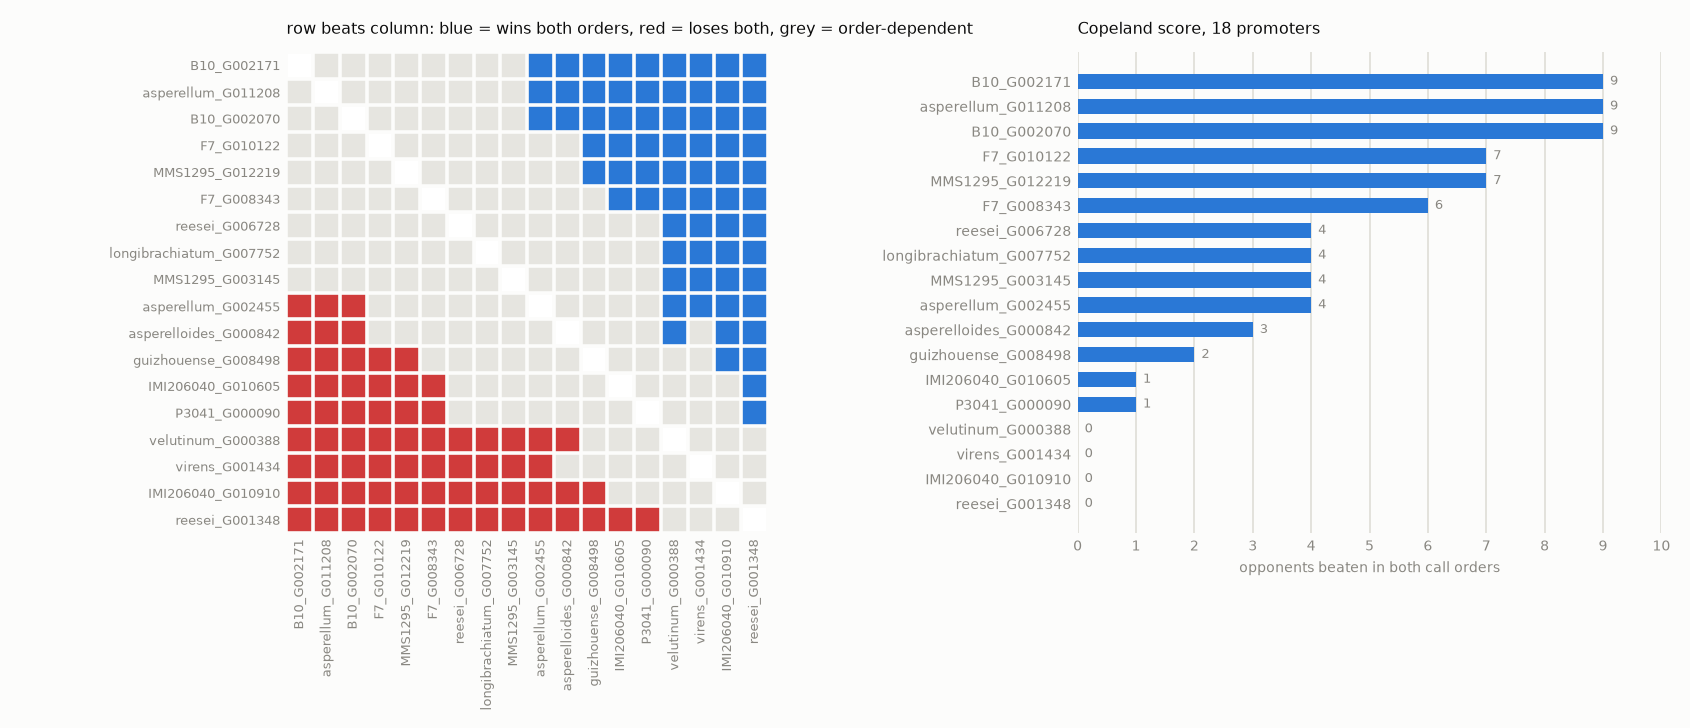

In [12]:
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"
BLUE, RED, NEUTRAL = "#2a78d6", "#d03b3b", "#e6e5e0"

matrix = np.full((len(order), len(order)), np.nan)
for i, a in enumerate(order):
    for j, b in enumerate(order):
        if i != j:
            matrix[i, j] = 1 if (a, b) in strict_beats else -1 if (b, a) in strict_beats else 0

fig, (ax, bx) = plt.subplots(
    1, 2, figsize=(13, 5.6), width_ratios=[1.35, 1], facecolor=SURFACE)

cmap = ListedColormap([RED, NEUTRAL, BLUE])
cmap.set_bad("#ffffff")
ax.imshow(matrix, cmap=cmap, norm=BoundaryNorm([-1.5, -0.5, 0.5, 1.5], 3))
ax.set_xticks(range(len(order)), order, rotation=90, fontsize=7, color=MUTED)
ax.set_yticks(range(len(order)), order, fontsize=7, color=MUTED)
ax.set_xticks(np.arange(len(order) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(order) + 1) - 0.5, minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="both", length=0)
ax.set_title("row beats column: blue = wins both orders, red = loses both, "
             "grey = order-dependent", fontsize=9, color=INK, loc="left", pad=10)
for side in ax.spines.values():
    side.set_visible(False)

bars = [copeland[n] for n in order]
bx.barh(range(len(order)), bars, color=BLUE, height=0.62)
bx.invert_yaxis()
bx.set_yticks(range(len(order)), order, fontsize=7, color=MUTED)
bx.set_xlabel("opponents beaten in both call orders", fontsize=8, color=MUTED)
bx.set_xticks(range(0, max(bars) + 2))
bx.tick_params(colors=MUTED, labelsize=8, length=0)
bx.grid(axis="x", color=GRID, linewidth=1)
bx.set_axisbelow(True)
bx.set_title(f"Copeland score, {SUBSET} promoters", fontsize=9, color=INK,
             loc="left", pad=10)
for side in bx.spines.values():
    side.set_visible(False)
for i, v in enumerate(bars):
    bx.text(v + 0.12, i, str(v), va="center", fontsize=7, color=MUTED)

fig.patch.set_facecolor(SURFACE)
for axis in (ax, bx):
    axis.set_facecolor(SURFACE)
fig.tight_layout()
plt.show()

## Summary

In [13]:
summary = pd.DataFrame([
    ("deterministic",
     "yes" if DETERMINISTIC else "no",
     f"{len(by_pair)} pairs x {REPEATS} repeats, {len(unstable)} disagreed with itself"),
    ("symmetric",
     "no" if SYMMETRIC_RATE < 1 else "yes",
     f"{SYMMETRIC_RATE:.0%} of {len(sym_pairs)} pairs survive an order swap; "
     f"slot A wins {slot_bias[0] / sum(slot_bias.values()):.0%} of all calls"),
    ("transitive (naive, 1 call/pair)",
     "no" if naive_cycles else "yes",
     f"{len(naive_cycles)}/{n_triples} cyclic triples"),
    ("transitive (debiased, 2 calls/pair)",
     "no" if strict_cycles else "yes",
     f"{len(strict_cycles)}/{n_triples} cyclic triples over {sum(chains.values())} "
     f"a>b>c chains; {len(flipped)}/{len(pairs)} pairs undecidable"),
], columns=["property", "holds", "evidence"])

print(f"total /sedzia calls spent: {_calls['total']}\n")
summary

total /sedzia calls spent: 786



,property,holds,evidence
0,deterministic,yes,"40 pairs x 5 repeats, 0 disagreed with itself"
1,symmetric,no,55% of 100 pairs survive an order swap; slot A wins 72% of all calls
2,"transitive (naive, 1 call/pair)",no,46/816 cyclic triples
3,"transitive (debiased, 2 calls/pair)",yes,0/816 cyclic triples over 43 a>b>c chains; 83/153 pairs undecidable


**How to use the judge, given the above**

1. Ask every pair **twice**, once in each order, and treat a flip as a tie. A single
   call is a biased comparison, not a measurement.
2. Do not `sorted(..., key=cmp_to_key(judge))`. The raw comparator is not a strict
   weak ordering, and Timsort on an inconsistent comparator produces an arbitrary
   permutation. Score candidates by Copeland points from a round robin (or a
   Swiss-style subset) instead.
3. Near-ties are cheap to detect and expensive to resolve -- if two candidates flip
   with call order, the judge is telling you it cannot separate them, so spend the
   remaining call budget elsewhere.
4. Re-run the determinism cell in any new session before trusting cached verdicts;
   what this notebook establishes is stability *within a session*.

In [17]:
promoters

,nazwa,gatunek,gatunek_krotko,genom,dlugosc,N,sekwencja
0,B10_G000242,B10,B10,B10,800,0,TGCCTGGTTGACACGCTTGACGTTACCAAAACATTTCATATGGTGC...
1,F7_G010122,F7,F7,F7,800,0,AATGAAAGATGAGCTAAGAGATTATGGATATCAGACATGCCCTTTC...
2,I1237_G008125,I1237,I1237,I1237,800,0,AGGAACTGTCATCAAGATAATCGTGAAGAAAATCATACTTGACGGC...
3,MMS1295_G010217,MMS1295,MMS1295,MMS1295,800,0,TGTTGTATTATTTTGTTCTATGGAGCTTATAGATACGTTAATGCAA...
4,N1508_G009601,N1508,N1508,N1508,800,0,CTTTGTTCTCCATATTGCGTGGAGCTAGAGTTGCGGTATGTCTCAC...
...,...,...,...,...,...,...,...
95,F7_G006828,F7,F7,F7,800,0,CACCGGGGCCAGCCCCTCTGTGCCTACTTTGTATACTCAAATTCTC...
96,I1237_G010182,I1237,I1237,I1237,800,0,CGAGAAGCTACATGGGTAGCTTAGGGCAGCAGTGGTTATGATGAGC...
97,MMS1295_G012219,MMS1295,MMS1295,MMS1295,800,0,TTCGAGAAGCTGGAGTTGAGCTTTTCGAAGAAGAAGCTAGCAGTGA...
98,N1508_G000826,N1508,N1508,N1508,800,0,TGATTGATTGGATGTGAGGGCTGTTGATGTGGGTGGTTTTTTTTTG...


In [22]:
promoters.rename(columns={"nazwa": "id", "sekwencja": "sequence"}, inplace=True)
promoters

,id,gatunek,gatunek_krotko,genom,dlugosc,N,sequence
0,B10_G000242,B10,B10,B10,800,0,TGCCTGGTTGACACGCTTGACGTTACCAAAACATTTCATATGGTGC...
1,F7_G010122,F7,F7,F7,800,0,AATGAAAGATGAGCTAAGAGATTATGGATATCAGACATGCCCTTTC...
2,I1237_G008125,I1237,I1237,I1237,800,0,AGGAACTGTCATCAAGATAATCGTGAAGAAAATCATACTTGACGGC...
3,MMS1295_G010217,MMS1295,MMS1295,MMS1295,800,0,TGTTGTATTATTTTGTTCTATGGAGCTTATAGATACGTTAATGCAA...
4,N1508_G009601,N1508,N1508,N1508,800,0,CTTTGTTCTCCATATTGCGTGGAGCTAGAGTTGCGGTATGTCTCAC...
...,...,...,...,...,...,...,...
95,F7_G006828,F7,F7,F7,800,0,CACCGGGGCCAGCCCCTCTGTGCCTACTTTGTATACTCAAATTCTC...
96,I1237_G010182,I1237,I1237,I1237,800,0,CGAGAAGCTACATGGGTAGCTTAGGGCAGCAGTGGTTATGATGAGC...
97,MMS1295_G012219,MMS1295,MMS1295,MMS1295,800,0,TTCGAGAAGCTGGAGTTGAGCTTTTCGAAGAAGAAGCTAGCAGTGA...
98,N1508_G000826,N1508,N1508,N1508,800,0,TGATTGATTGGATGTGAGGGCTGTTGATGTGGGTGGTTTTTTTTTG...


In [23]:
from src.hack_the_bromoter.judge import sort_sequences, bucket_sort_sequences

sorted_sequences = sort_sequences(promoters, judge_many)
sorted_sequences

['F7_G010122',
 'I1237_G010182',
 'MMS1295_G010217',
 'B10_G002171',
 'B10_G002070',
 'F7_G001378',
 'N1508_G012052',
 'P3041_G000090',
 'P3116_G007934',
 'asperelloides_G000842',
 'harzianum_G009907',
 'F7_G001021',
 'asperelloides_G006264',
 'asperellum_G002455',
 'IMI206040_G008788',
 'citrinoviride_G001765',
 'guizhouense_G008498',
 'P1_G005351',
 'citrinoviride_G004951',
 'B10_G006120',
 'I1237_G005321',
 'harzianum_G000318',
 'longibrachiatum_G009794',
 'MMS1295_G009579',
 'P3080_G004656',
 'asperelloides_G006266',
 'asperellum_G002095',
 'P3041_G007425',
 'IMI206040_G010605',
 'guizhouense_G000843',
 'harzianum_G003944',
 'longibrachiatum_G010676',
 'reesei_G003563',
 'velutinum_G012213',
 'MMS1295_G003145',
 'N1508_G010380',
 'P3116_G007763',
 'asperellum_G011208',
 'virens_G005807',
 'P3080_G000512',
 'asperelloides_G000844',
 'MMS1295_G012219',
 'N1508_G000826',
 'P3041_G000688',
 'IMI206040_G007782',
 'P1_G006612',
 'citrinoviride_G001754',
 'guizhouense_G008497',
 'N1508_G0

In [24]:
buckeet_sorted_seq = bucket_sort_sequences(promoters, judge_many)
buckeet_sorted_seq

[['harzianum_G011583',
  'F7_G010122',
  'F7_G001378',
  'reesei_G003563',
  'B10_G009090',
  'N1508_G004261',
  'I1237_G010182',
  'MMS1295_G010217',
  'asperelloides_G000842',
  'B10_G002171'],
 ['B10_G002070',
  'citrinoviride_G004951',
  'MMS1295_G003145',
  'P3116_G007763',
  'asperelloides_G000844',
  'MMS1295_G006281',
  'P3080_G000799',
  'P3116_G004390',
  'asperelloides_G004830',
  'longibrachiatum_G007752'],
 ['B10_G010636',
  'MMS1295_G012219',
  'P3041_G000688',
  'harzianum_G009907',
  'MMS1295_G005194',
  'N1508_G010381',
  'asperelloides_G006264',
  'asperellum_G002455',
  'IMI206040_G008788',
  'citrinoviride_G001765'],
 ['harzianum_G000318',
  'N1508_G012052',
  'P3080_G004656',
  'asperellum_G002095',
  'P1_G005351',
  'guizhouense_G000843',
  'longibrachiatum_G010676',
  'B10_G006120',
  'I1237_G005321',
  'N1508_G010380'],
 ['P3080_G000512',
  'asperellum_G011208',
  'P1_G006612',
  'guizhouense_G008497',
  'virens_G002853',
  'I1237_G005324',
  'IMI206040_G007781'